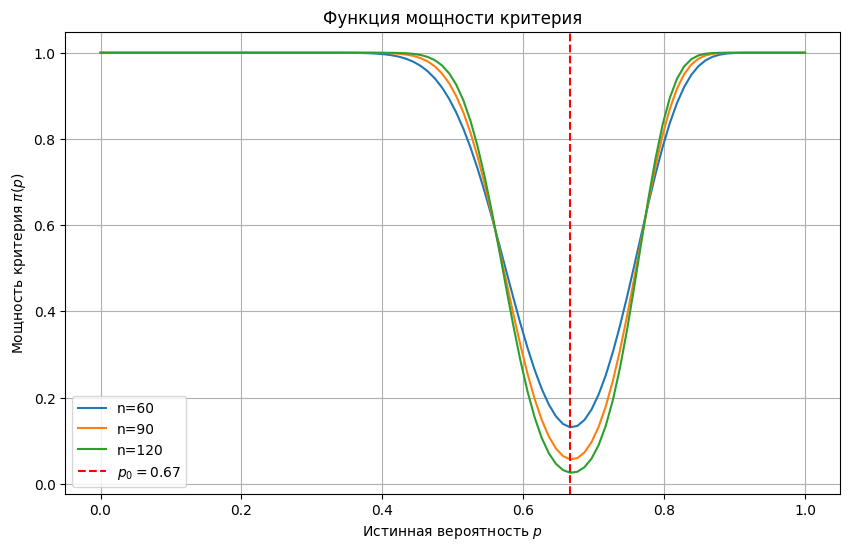

n = 60: α = 0.1310, β = 0.1225
n = 90: α = 0.0566, β = 0.0851
n = 120: α = 0.0255, β = 0.0602


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Параметры
p0 = 2/3  # Гипотетическая вероятность
delta = 0.15  # Максимальное отклонение
n_list = [60, 90, 120]  # Объемы выборки
p_range = np.linspace(0, 1, 100)  # Диапазон p для анализа

# Функция для расчета мощности
def power_function(n, p):
    k_low = int(np.floor(n * (p0 - delta*p0)))
    k_high = int(np.ceil(n * (p0 + delta*p0)))
    prob_low = binom.cdf(k_low, n, p)
    prob_high = 1 - binom.cdf(k_high - 1, n, p)
    return prob_low + prob_high

# Построение графиков
plt.figure(figsize=(10, 6))
for n in n_list:
    power = [power_function(n, p) for p in p_range]
    plt.plot(p_range, power, label=f'n={n}')

plt.axvline(p0, color='red', linestyle='--', label=f'$p_0 = {p0:.2f}$')
plt.xlabel('Истинная вероятность $p$')
plt.ylabel('Мощность критерия $\\pi(p)$')
plt.title('Функция мощности критерия')
plt.legend()
plt.grid()
plt.show()
# Вычисление α и β для каждого n
for n in n_list:
    alpha = power_function(n, p0)
    beta = 1 - power_function(n, 0.5)
    print(f'n = {n}: α = {alpha:.4f}, β = {beta:.4f}')

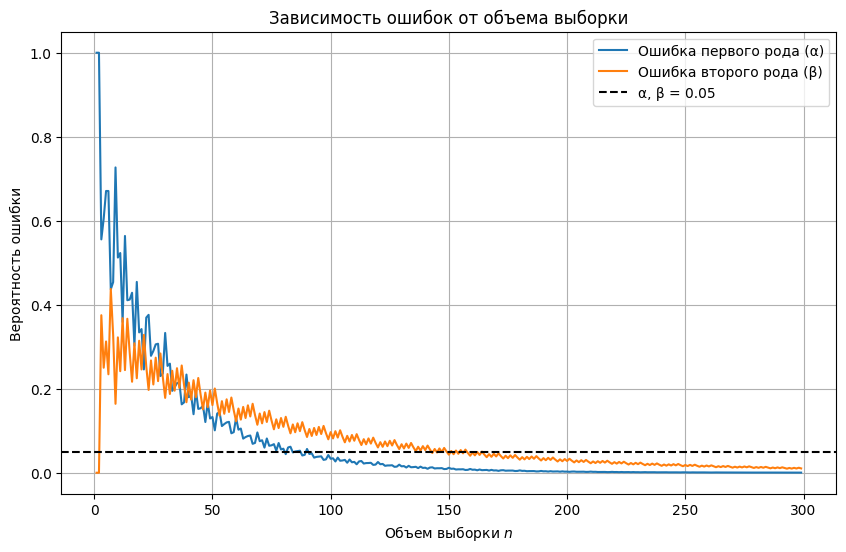

Минимальный объем выборки 143


In [4]:
#Графики зависимости ошибок от объема выборки
n_values = np.arange(1, 300)
alpha_values = []
beta_values = []

for n in n_values:
    alpha = power_function(n, p0)
    beta = 1 - power_function(n, 0.5)
    alpha_values.append(alpha)
    beta_values.append(beta)

plt.figure(figsize=(10, 6))
plt.plot(n_values, alpha_values, label='Ошибка первого рода (α)')
plt.plot(n_values, beta_values, label='Ошибка второго рода (β)')
plt.axhline(0.05, color='black', linestyle='--', label='α, β = 0.05')
plt.xlabel('Объем выборки $n$')
plt.ylabel('Вероятность ошибки')
plt.title('Зависимость ошибок от объема выборки')
plt.legend()
plt.grid()
plt.show()
# Поиск минимального n, где α и β ≤ 0.05
min_n = 0
for n, alpha, beta in zip(n_values, alpha_values, beta_values):
    if alpha <= 0.05 and beta <= 0.05:
        min_n = n
        break
print(f'Минимальный объем выборки', n)
# По графику видно что минимальный обьем выборки при котором вероятности ошибок не больше 0.05 примерно 150